#Project Title:
**E-Commerce Supply Chain & Delivery Performance Optimization**

#1. Business Problem
An international e-commerce marketplace is experiencing a rise in customer churn and a dip in customer satisfaction scores (CSAT). Preliminary reviews suggest the bottleneck is in logistics: frequent delayed deliveries, inefficient shipping routes, and high return rates due to late arrivals. The company is losing millions in operational inefficiencies and "late delivery" compensation vouchers.



# 2. Objective
To analyze historical supply chain, order, and delivery data to identify the root causes of delivery delays, optimize shipping carrier performance, reduce operational costs, and build an interactive executive dashboard that allows the operations team to monitor logistics health in real time.



# 3. Data Source
The Dataset: Olist Brazilian E-Commerce Dataset (Available publicly on Kaggle).

Why it's real-world: This is real, commercial, anonymized data from a massive marketplace. It consists of over 100,000 orders from 2016 to 2018.

Structure: It is a relational database spread across 9 CSV files (Orders, Order Items, Customers, Payments, Reviews, Products, Sellers, Geolocation, and Category Translation). This requires you to demonstrate strong SQL or Pandas joining skills—a massive green flag for recruiters.



#4. Tools & Requirements
Data Extraction & Cleaning: Python (Pandas/NumPy)

Exploratory Data Analysis (EDA): Python (Matplotlib, Seaborn)

BI Dashboarding: Power BI

Documentation/Portfolio: GitHub

#5. Methodology & Step-by-Step Execution

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt
sns.set_theme(style="whitegrid") # plotting style

In [2]:
#Load the Data
orders = pd.read_csv('/content/olist_orders_dataset.csv')
items = pd.read_csv('/content/olist_order_items_dataset.csv')
reviews = pd.read_csv('/content/olist_order_reviews_dataset.csv')
sellers = pd.read_csv('/content/olist_sellers_dataset.csv')
translation = pd.read_csv('/content/product_category_name_translation.csv')
products = pd.read_csv('/content/olist_products_dataset.csv')

In [3]:
# Inspect the dataset
print(orders.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB
None


**Phase 2: Data Merging & Cleaning**

In [4]:
#Convert Timestamps
timestamp_cols = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]

for col in timestamp_cols:
    orders[col] = pd.to_datetime(orders[col])

In [5]:
#Handle Missing Data
orders_cleaned = orders.dropna(subset=['order_delivered_customer_date']).copy()

In [6]:
#Merge the Datasets
# Merge orders with order items (freight value and seller IDs)
master_df = pd.merge(orders_cleaned, items, on='order_id', how='inner')

# Merge with reviews (to see how delays affect customer satisfaction)
master_df = pd.merge(master_df, reviews[['order_id', 'review_score']], on='order_id', how='left')

# Merge with products and translations to get English category names
master_df = pd.merge(master_df, products[['product_id', 'product_category_name']], on='product_id', how='left')
master_df = pd.merge(master_df, translation, on='product_category_name', how='left')

# Drop the Portuguese category column to keep it clean
master_df.drop(columns=['product_category_name'], inplace=True)

#Phase 3: Feature Engineering (Creating KPIs)

In [7]:
# 1. Total Delivery Time (Days)
# Actual time taken from purchase to customer doorstep
master_df['actual_delivery_days'] = (master_df['order_delivered_customer_date'] - master_df['order_purchase_timestamp']).dt.total_seconds() / 86400

In [8]:
# 2. Seller Handling Time (Days)
# Time taken by seller to hand over package to logistics carrier
master_df['seller_handling_days'] = (master_df['order_delivered_carrier_date'] - master_df['order_purchase_timestamp']).dt.total_seconds() / 86400

In [9]:
# 3. Carrier Transit Time (Days)
# Time taken by carrier to deliver once they receive it
master_df['carrier_transit_days'] = (master_df['order_delivered_customer_date'] - master_df['order_delivered_carrier_date']).dt.total_seconds() / 86400

In [10]:
# 4. Delivery Buffer (Days)
# Estimated Delivery Date minus Actual Delivery Date
master_df['delivery_buffer_days'] = (master_df['order_estimated_delivery_date'] - master_df['order_delivered_customer_date']).dt.total_seconds() / 86400

In [11]:
# 5. Is Late Flag (Binary target for analysis)
master_df['is_late'] = np.where(master_df['delivery_buffer_days'] < 0, 1, 0)

#Phase 4: Exploratory Data Analysis (EDA)

In [12]:
#Analysis 1:Calculate the average review score for On-Time vs. Late deliveries.
review_analysis = master_df.groupby('is_late')['review_score'].mean().reset_index()
review_analysis['is_late'] = review_analysis['is_late'].map({0: 'On-Time', 1: 'Late'})
print(review_analysis)

   is_late  review_score
0  On-Time      4.210476
1     Late      2.548884


In [13]:
#Analysis 2:Where the bottleneck occurs for late deliveries.
late_orders = master_df[master_df['is_late'] == 1]
print("Avg Seller Handling Time for Late Orders:", late_orders['seller_handling_days'].mean())
print("Avg Carrier Transit Time for Late Orders:", late_orders['carrier_transit_days'].mean())

Avg Seller Handling Time for Late Orders: 6.011089021881676
Avg Carrier Transit Time for Late Orders: 25.34169474321552


#Phase 5:Data Visualization

/tmp/ipykernel_17377/1883609236.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


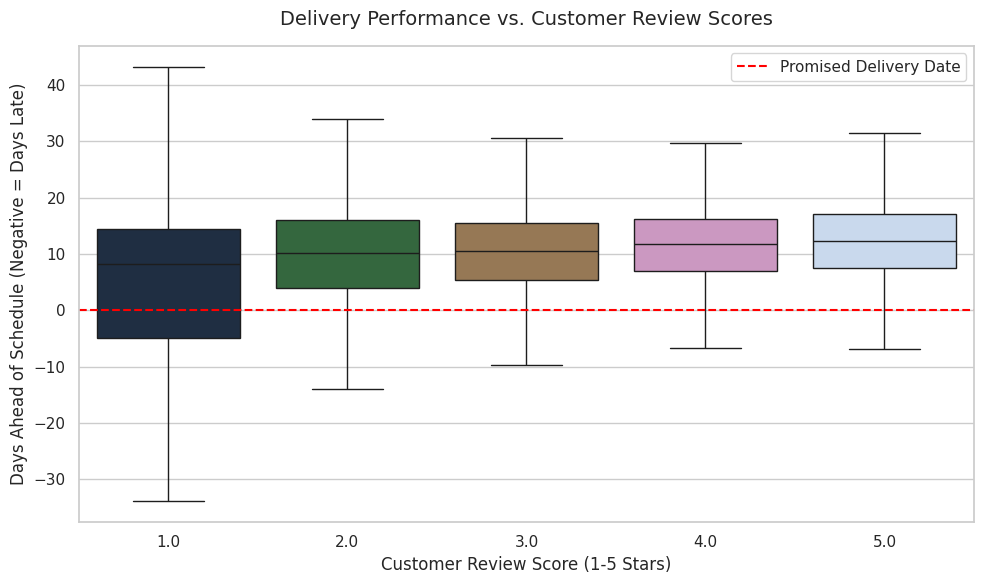

In [18]:
#1. The Correlation: How Late Deliveries Impact Review Scores
plt.figure(figsize=(10, 6))
sns.boxplot(
    data=master_df,
    x='review_score',
    y='delivery_buffer_days',
    palette='cubehelix',
    showfliers=False
)
plt.axhline(y=0, color='red', linestyle='--', label='Promised Delivery Date')
plt.title('Delivery Performance vs. Customer Review Scores', fontsize=14, pad=15)
plt.xlabel('Customer Review Score (1-5 Stars)', fontsize=12)
plt.ylabel('Days Ahead of Schedule (Negative = Days Late)', fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()

/tmp/ipykernel_17377/2382416117.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


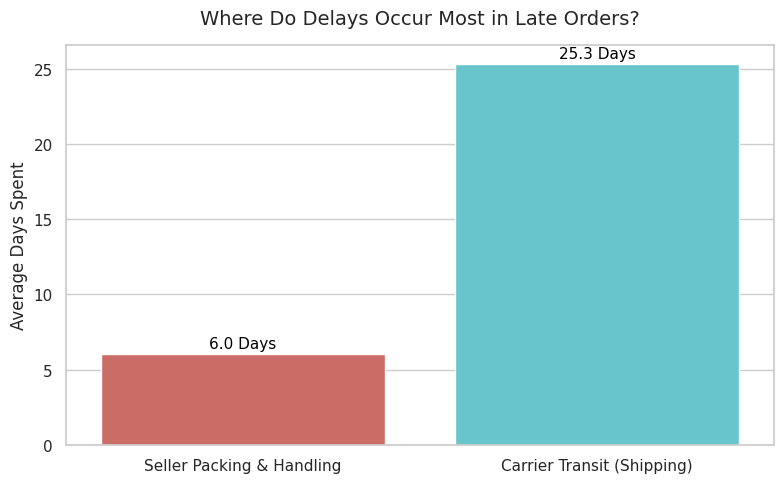

In [21]:
#2. The Bottleneck: Seller Delay vs. Carrier Transit Delay
late_orders = master_df[master_df['is_late'] == 1]

avg_phases = late_orders[['seller_handling_days', 'carrier_transit_days']].mean().reset_index()
avg_phases.columns = ['Phase', 'Average Days']
avg_phases['Phase'] = avg_phases['Phase'].map({
    'seller_handling_days': 'Seller Packing & Handling',
    'carrier_transit_days': 'Carrier Transit (Shipping)'
})

plt.figure(figsize=(8, 5))
sns.barplot(
    data=avg_phases,
    x='Phase',
    y='Average Days',
    palette='hls'
)
plt.title('Where Do Delays Occur Most in Late Orders?', fontsize=14, pad=15)
plt.ylabel('Average Days Spent', fontsize=12)
plt.xlabel('', fontsize=12)

# Add data labels
for index, row in avg_phases.iterrows():
    plt.text(index, row['Average Days'] + 0.2, f"{row['Average Days']:.1f} Days", color='black', ha="center", va="bottom", fontsize=11)

plt.tight_layout()
plt.show()

/tmp/ipykernel_17377/1760764146.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


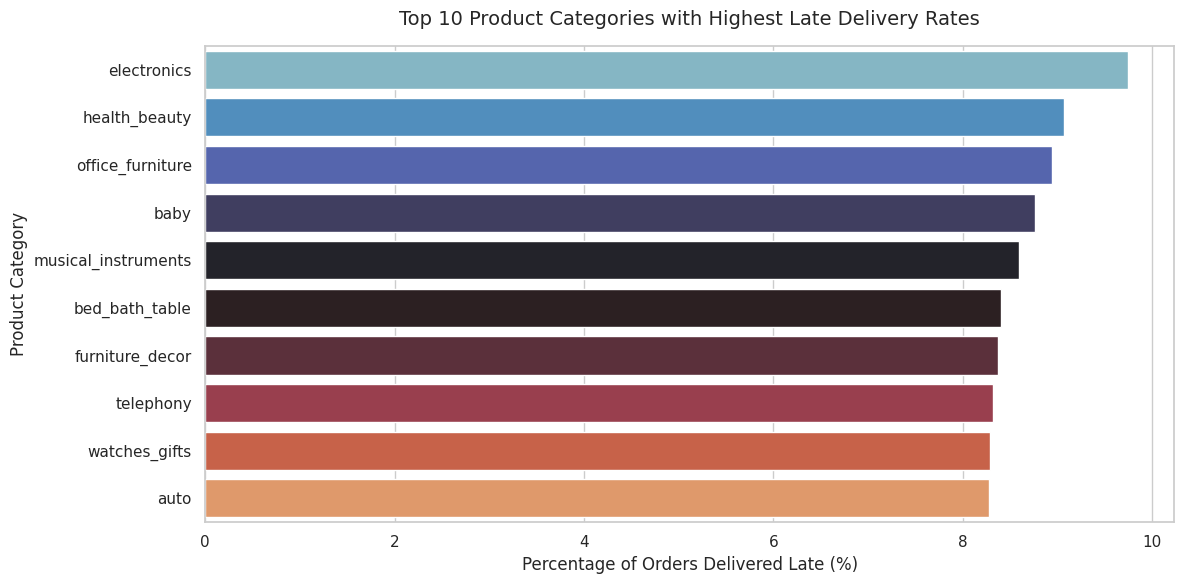

In [22]:
#3. Volume vs. Lateness
category_stats = master_df.groupby('product_category_name_english').agg(
    total_orders=('order_id', 'count'),
    late_orders=('is_late', 'sum')
).reset_index()

category_stats['late_rate (%)'] = (category_stats['late_orders'] / category_stats['total_orders']) * 100

top_problematic_categories = category_stats[category_stats['total_orders'] > 500].sort_values(by='late_rate (%)', ascending=False).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(
    data=top_problematic_categories,
    y='product_category_name_english',
    x='late_rate (%)',
    palette='icefire'
)
plt.title('Top 10 Product Categories with Highest Late Delivery Rates', fontsize=14, pad=15)
plt.xlabel('Percentage of Orders Delivered Late (%)', fontsize=12)
plt.ylabel('Product Category', fontsize=12)
plt.tight_layout()
plt.show()

#Phase 6:Export Cleaned Data for Dashboarding

In [24]:
master_df.to_csv('olist_supply_chain_cleaned.csv', index=False)

In [26]:
# 1. Read the customer dataset
customers = pd.read_csv('/content/olist_customers_dataset.csv')

# Look closely at the actual columns in your file to avoid matching issues
print("Actual customer columns found:", customers.columns.tolist())

# Determine the correct state column name dynamically
state_col = None
for col in ['customer_state', 'state', 'customer_status']:
    if col in customers.columns:
        state_col = col
        break

if state_col is not None:
    # Rename it locally to 'customer_state' if it was named something else
    if state_col != 'customer_state':
        customers.rename(columns={state_col: 'customer_state'}, inplace=True)

    # Merge safely into master_df
    if 'customer_state' not in master_df.columns:
        master_df = pd.merge(master_df, customers[['customer_id', 'customer_state']], on='customer_id', how='left')
else:
    print("Warning: Could not find a state column. Creating a placeholder to keep your export stable.")
    master_df['customer_state'] = 'Unknown'

# 2. Add 'customer_state' to your export list safely
columns_to_export = [
    'order_id', 'customer_id', 'seller_id', 'product_id',
    'order_status', 'order_purchase_timestamp', 'order_delivered_customer_date',
    'order_estimated_delivery_date', 'price', 'freight_value',
    'review_score', 'product_category_name_english',
    'actual_delivery_days', 'seller_handling_days',
    'carrier_transit_days', 'delivery_buffer_days', 'is_late',
    'customer_state'
]

final_dashboard_df = master_df[columns_to_export]

# 3. Export the file safely
final_dashboard_df.to_csv('olist_supply_chain_analytics.csv', index=False)
print("Data successfully re-exported to olist_supply_chain_analytics.csv!")

Actual customer columns found: ['customer_id', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state']
Data successfully re-exported to olist_supply_chain_analytics.csv!
